# US Gas Prices (2024 – Present)

## Retail Gasoline Prices: Actual Prices & Year-over-Year Change

### Description

This notebook provides a technical visualization of U.S. retail gasoline price trends. It utilizes data from the Federal Reserve Economic Data (FRED) to compare:

- **Regular Grade:** Conventional Formulation (US Average)
- **Regular Grade:** All Formulations (US Average)
- **Unleaded Regular:** U.S. City Average
- **All Formulations:** U.S. City Average

The analysis tracks both actual weekly prices and year-over-year percentage changes to highlight gasoline price dynamics across formulation types and geographic aggregations.

---

## Objectives

- Analyze retail gasoline price trends from 2024 to present day
- Compare conventional vs. all-formulation pricing behaviors
- Identify periods of price acceleration and deceleration
- Provide a time-logged macroeconomic and energy market analysis

---

## Data Source

- Federal Reserve Economic Data (FRED)
  - `GASREGCOVW`: Regular Grade Conventional Gas Price, US Average (Weekly)
  - `GASREGW`: Regular Grade Gas Price, All Formulations, US Average (Weekly)
  - `APU000074714`: Average Price, Unleaded Regular, U.S. City Average
  - `APU00007471A`: Average Price, Gasoline, All Formulations, U.S. City Average

## Pre-Processing

### Install System Dependencies

In [1]:
!pip install pandas-datareader
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip

### Import Python Libraries

In [2]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Define Global Functions 


In [3]:
def add_event_lines(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=10,
                     fontweight='bold')
            
def add_event_lines_small(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=5,
                     fontweight='bold')

### Standard Unit Initial Timeframe

In [4]:
start = datetime(2023, 4, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(weeks=52)

## US Gasoline Trends (April 2024 -Present)
### Key Events
- 2024 Presidential Election
- 2025 Inaugurattion of Donald J. Trump
- US Global Tariff Poliy enters effect
- 2025 Government Shutdown
- Iran War

In [5]:
gas_series = {
    'Regular, Conventional': {'id': 'GASREGCOVW', 'color': '#040404'},
    'Regular, All Formulations': {'id': 'GASREGW',    'color': '#e22222'},
    'Unleaded Regular, City Avg': {'id': 'APU000074714', 'color': '#05c10e'},
    'All Formulations, City Avg': {'id': 'APU00007471A', 'color': '#2e0cc3'}
}

events = [
    ('2024-11-04', '2024 Presidential Election'),
    ('2025-01-20', 'Donald Trump Enters Second Presidential Term'),
    ('2025-04-15', 'Trump Imposes Global Foreign Trade Policy'),
    ('2025-10-01', 'Congressional ACH Appropriation Shutdown'),
    ('2026-02-28', 'IRGC Closes Strait of Hormuz'),
]

raw_data = {}
transformed_data = {}


/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_89631/1594246625.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_wow = (df_raw.pct_change(periods=52) * 100)


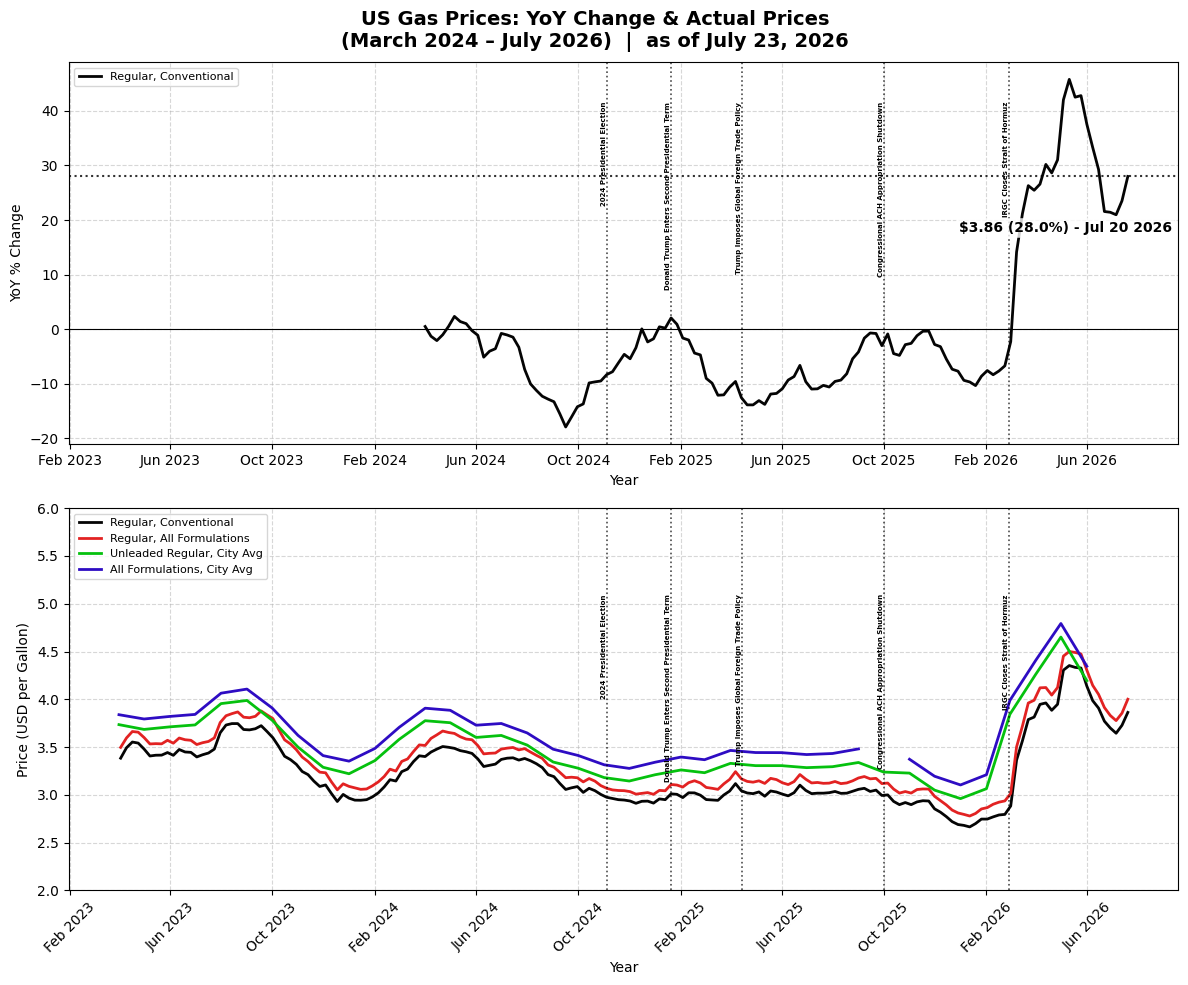

In [12]:


for label, meta in gas_series.items():
    df_raw = web.DataReader(meta['id'], 'fred', start, end)
    raw_data[label] = df_raw
    df_wow = (df_raw.pct_change(periods=52) * 100)
    transformed_data[label] = df_wow[df_wow.index >= plot_start]

r_date = transformed_data['Regular, Conventional'].index[-1]
r_val = transformed_data['Regular, Conventional'].iloc[-1, 0]
r_price = raw_data['Regular, Conventional'].iloc[-1, 0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Year-over-Year Percentage Change
# Note: Uncomment lines below to render all formulations on the YoY visualization
ax1.plot(transformed_data['Regular, Conventional'], label='Regular, Conventional', color=gas_series['Regular, Conventional']['color'], linewidth=2)
# ax1.plot(transformed_data['Regular, All Formulations'], label='Regular, All Formulations', color=gas_series['Regular, All Formulations']['color'], linewidth=2)
# ax1.plot(transformed_data['Unleaded Regular, City Avg'], label='Unleaded Regular, City Avg', color=gas_series['Unleaded Regular, City Avg']['color'], linewidth=2)
# ax1.plot(transformed_data['All Formulations, City Avg'], label='All Formulations, City Avg', color=gas_series['All Formulations, City Avg']['color'], linewidth=2)

ax1.set_ylabel('YoY % Change')
ax1.axhline(0, color='black', linewidth=0.8)

ax2.set_ylim(2, 6)
for label, df_raw in raw_data.items():
    ax2.plot(df_raw, label=label, color=gas_series[label]['color'], linewidth=2)
ax2.set_ylabel('Price (USD per Gallon)')

df_ref = list(raw_data.values())[0]

for ax in [ax1, ax2]:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)
    
    y_pos = ax.get_ylim()[1] * 0.85
    for date_str, label in events:
        evt_date = pd.to_datetime(date_str)
        if df_ref.index.min() <= evt_date <= df_ref.index.max():
            ax.axvline(x=evt_date, 
                       color='black', 
                       linestyle=':', 
                       linewidth=1.2, 
                       alpha=0.7)
            ax.text(evt_date, 
                    y_pos, 
                    label, 
                    rotation=90, 
                    verticalalignment='top', 
                    horizontalalignment='right', 
                    fontsize=5, 
                    fontweight='bold')

ax1.tick_params(axis='x', labelbottom=True)
ax1.set_xlabel('Year')
ax2.set_xlabel('Year')

ax1.annotate(f"${r_price:.2f} ({r_val:.1f}%) - {r_date.strftime('%b %d %Y')}", 
             xy=(r_date, r_val), 
             textcoords="offset points", 
             xytext=(-45, -40), 
             ha='center', 
             weight='bold', 
             color='black',
             bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec='none'))

ax1.axhline(y=r_val, 
            color="#000000", 
            linestyle=':', 
            linewidth=1.5, 
            alpha=0.8)

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) 
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) 
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
plt.xticks(rotation=45)

fig.suptitle(f'US Gas Prices: YoY Change & Actual Prices\n({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})  |  as of {str_current_date}',
             fontsize=14, 
             fontweight='bold')
plt.tight_layout()
plt.show()

# Conclusions and Observations

### Fuel and Energy – 10 July 2026

#### The Price at the Pump is Lying to You

On Wednesday, July 8, 2026, while present at the NATO summit in Ankara, Turkey, President Dondald Trump declared the ceasefire with Iran 'over.' 

Shortly afterwards, more than 80 milittary sites in Iran were struk by U.S military forces. Oil prices were released prior to these events.

According to AAA, the national average price for a gas rose 5 cents per gallon overnight, to **$3.84 per gallon**.

##### Conventional Gas Prices

Gas prices were previously showingg decline following a substantial increaes is shipping traffic through the Strait of Hormuz. 

As of Wednesday, July 7, 2026, prior to military intervention, FRED reports that regular grade conventional gas reaced **$3.777/gallon**, slight up from previous figures at **$3.771/gallon**.

Conventional oil came in at **$3.645/gallon** on Wednesday down from **$3.700/gallon** at the end of June.

##### Prices in Urban Areas

Urban prices are scheduled for release on July 14, 2026. This Notebook will be updated according to reflect reported urban prices.

##### The Good News

Prices appear to be nearing a stale point between $3.40 and $3.60 per gallon nationwide.

This is indicative of a larger strategy regarding the United States and global energy markets.

##### The Bad News

America's plan of intervening in a proxy war, no one was fighting... 

Started by a radical group in a completely different country than the participants...

Led by a country 1/10 the population of their mutual 'adversary'...

Over the ingredients to bake an explosive cake in the absence of ovens or occaisions...

After intervening several months prior with these same countries resulting in mutual deferrment of hostilities...

Definitly showed its global drawbacks over the last week and continues to show the abject failure it truly is each and every day until its very last breath.

##### Closing

Generally, things are more likely to get worse, far before they ever begin to resemble "normal."

___

**Thank you for reading. I'm looking into alternative methods of travel. Unfortunately, I'm not trained to ride a horse — and I'm no cowboy.**

**<u>U.S. Automotive Markets</u> and <u>U.S. Grocery Supply Chains</u> caught my attention this week. Stay tuned for what happens next on the journey.**
___



#### Update Schedule

- ***U.S. Regular - Jul 28, 2026***

    1. `GASREGCOVW`: **Conventional (Weekly)**
    2. `GASREGW`: **All Formulations (Weekly)**
    
- ***U.S. City Average - Jul 28, 2026***

    3. `APU000074714`: **Unleaded Regular**
    4. `APU00007471A`: **All Formulations**

#### Data Changelog / Notes

#### ***Review and analysis publishing on Friday, July 31, 2026, at 1:30 P.M. Pacific Time.***